# Introduction to Modeling Flexibility

Compare a traditional DCF, a realized market path with a fixed horizon, and a stop-gain resale policy. This continues the resale timing example in Chapter 9 of {cite}`farevuu2018`.

## Goal
Keep market history intact while a declared policy controls investment cashflows. Rules are evaluated at period end. A sale includes that period's operating cashflow and sale proceeds; later investment cashflows are zero.

## Setup

In [1]:
%matplotlib inline
from datetime import date
from uuid import uuid4
import os, sys
import polars as pl  # Detached tables for presentation only.
pl.Config.set_tbl_cols(-1)
import matplotlib.pyplot as plt
import rangekeeper as rk
from rangekeeper.examples import investment
from rangekeeper.io import MemoryStore
from rangekeeper.execution import Executor
from rangekeeper.run import SolutionStatus, validate
from rangekeeper.adapters.plotting import plot_flows, plot_distribution, plot_pairs
from rangekeeper.calculations import series
from rangekeeper.model import Model, Metadata
from rangekeeper.model.flow import Flow, Movement
from rangekeeper.duration import Frequency, PeriodTiming, make_periods
from rangekeeper.model.distribution import Distribution
from rangekeeper.scenarios import market, replay
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.prop_cycle': plt.cycler(color=['#285f8f','#cf8b2e','#9c557a','#627c49','#737373'])})
print('Installed package:', rk.__file__)
assert not {'rangekeeper.flux','rangekeeper.dynamics','rangekeeper.policy','rangekeeper._legacy_duration'} & set(sys.modules)

Installed package: /Volumes/Data/Projects/Rangekeeper/src/rangekeeper/__init__.py


In [2]:
from rangekeeper.run import SolutionStatus
def execute(model, specification):
    store = MemoryStore()
    store.put(model)
    run = Executor(store).execute(specification)
    validate(run, resolver=store).raise_if_invalid()
    assert run.report.status.solution is SolutionStatus.FEASIBLE, [(d.code, d.message) for d in run.report.diagnostics]
    output = store.load_model(run.record.outputs[0])
    return investment.report(output), run

def metrics(result):
    return {'PV (AUD)': result.pv.magnitude, 'NPV (AUD)': result.npv.magnitude,
            'Dated IRR (%)': 100 * result.irr.rate, 'Sale date': result.sale_date}

## Steps
### 1. Solve the traditional DCF

In [3]:
traditional_model = investment.formulate(investment.author())
traditional, traditional_run = execute(traditional_model, investment.specify(traditional_model))
metrics(traditional)

{'PV (AUD)': 999.9999999999997,
 'NPV (AUD)': -3.410605131648481e-13,
 'Dated IRR (%)': 6.996147845629787,
 'Sale date': datetime.date(2030, 12, 31)}

### 2. Realize one market path
Market pricing factors already include market growth, so this example sets the separate investment growth rate to zero.

In [4]:
parameters = {'num_periods': 10, 'growth_rate': 0.}
periods = make_periods(date(2021,1,1), frequency=Frequency.YEAR, count=11)
base_model = Model.create(metadata=Metadata(id=uuid4(), schema_version='0.7.0'))
plan = market.make_plan(periods=periods, seed=20261006, parameters={
    'volatility_per_period': .025, 'space_amplitude': .25, 'space_period': 10.,
    'space_phase': 0., 'growth_rate': .02, 'shock_likelihood': .02})
scenario = market.generate(base_model, plan, scenario_keys=['shared-example'])[0]

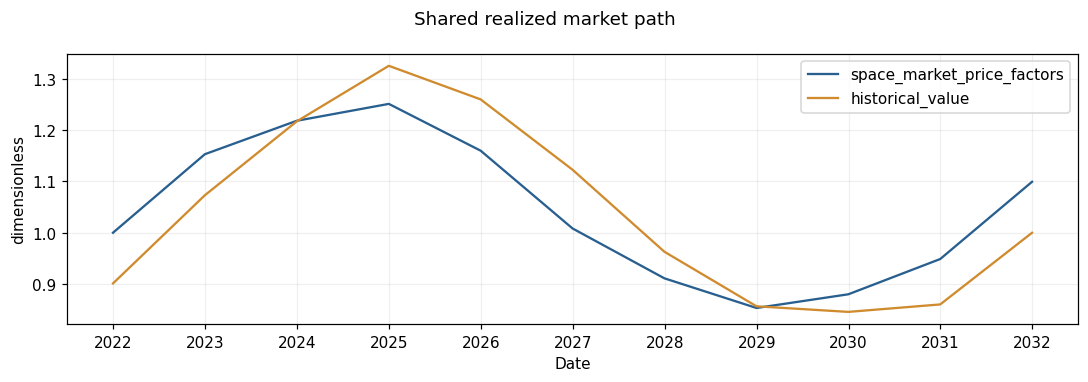

In [5]:
plot_flows({name: scenario.value(name).flow for name in ('space_market_price_factors','historical_value')}, title='Shared realized market path');

### 3. Declare and solve the fixed-horizon investment

In [6]:
model = investment.formulate(investment.author(parameters, scenario=scenario))
fixed, fixed_run = execute(model, investment.specify(model))

### 4. Declare a policy
Hold for at least three periods. Then sell at the first period end where the observed pricing factor is strictly greater than 1.2. Equality does not trigger. If no earlier rule triggers, sell at the final horizon.

In [7]:
policy = investment.build_stop_gain_resale_policy(model, threshold=1.2, minimum_holding_periods=3)
flexible_specification = investment.specify(model, policy=policy)
flexible, flexible_run = execute(model, flexible_specification)

### 5. Inspect decision evidence

In [8]:
pl.DataFrame([{'Date': d.at, 'Pricing factor': d.observations[0].quantity.magnitude, 'Rule': str(d.rule) if d.rule else 'fallback', 'Terminated': d.terminated, 'Reason': d.termination_reason} for d in flexible_run.report.outcomes])

Date,Pricing factor,Rule,Terminated,Reason
date,f64,str,bool,str
2021-12-31,1.0,"""fallback""",false,null
2022-12-31,1.153078,"""fallback""",false,null
2023-12-31,1.218242,"""5e0022cc-cd03-5f0a-954d-490467…",true,"""rule_matched"""


### 6. Compare cashflows and results

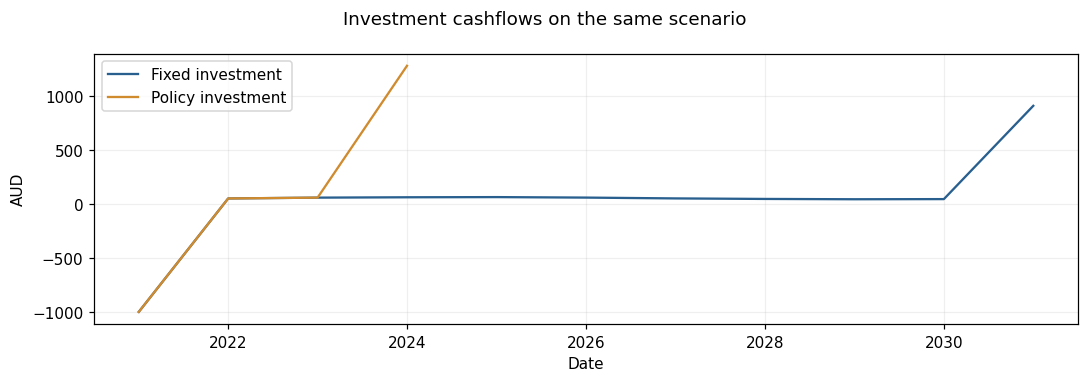

In [9]:
plot_flows({'Fixed investment': fixed.cashflows, 'Policy investment': flexible.cashflows}, title='Investment cashflows on the same scenario');

In [10]:
pl.DataFrame([{'Case': name, **metrics(result)} for name, result in [('Traditional', traditional), ('Fixed horizon', fixed), ('Policy', flexible)]])

Case,PV (AUD),NPV (AUD),Dated IRR (%),Sale date
str,f64,f64,f64,date
"""Traditional""",1000.0,-3.4106e-13,6.996148,2030-12-31
"""Fixed horizon""",807.982737,-192.017263,4.081749,2030-12-31
"""Policy""",1140.27799,140.27799,12.008884,2023-12-31


The policy may improve or reduce realized value. It observes a threshold, not the future peak. The full market path remains in both accepted Models. The horizon curve below is a hindsight comparison only.

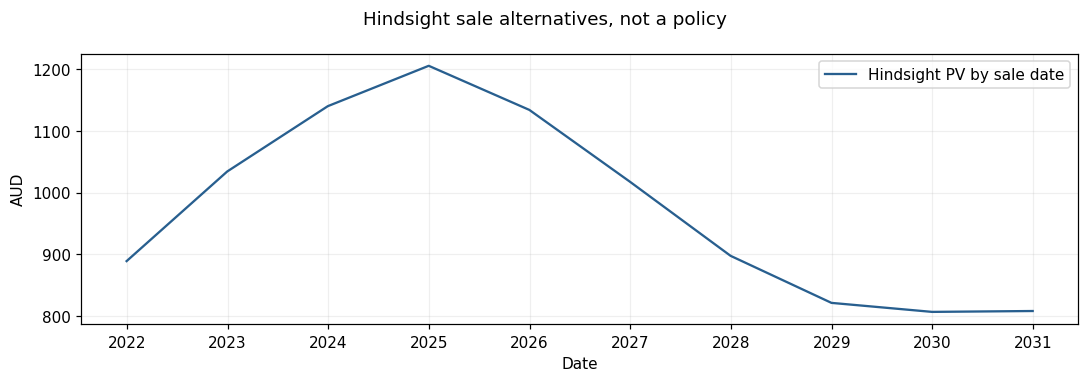

In [11]:
plot_flows({'Hindsight PV by sale date': investment.values(fixed.model)['horizon_pv'].flow}, title='Hindsight sale alternatives, not a policy');

## Checks

In [12]:
controlled = investment.values(flexible.model)
assert sum(m.magnitude for m in controlled['sale'].flow.movements) == 1
assert all(m.magnitude == 0 for m in controlled['total'].flow.movements if m.date > flexible.sale_date)
assert len(scenario.historical_value.flow.movements) == 11
assert all(d.observations[0].available_at <= d.at for d in flexible_run.report.outcomes)

In [13]:
assert not {'rangekeeper.flux','rangekeeper.dynamics','rangekeeper.policy','rangekeeper._legacy_duration'} & set(sys.modules)
print('Canonical records, explicit roles and installed consumer checks passed.')

Canonical records, explicit roles and installed consumer checks passed.


## Next Steps
Compare policies across many common realizations. A single scenario cannot establish expected policy performance.